In [ ]:
%pip install qiskit qiskit-ibm-runtime
!pip install qiskit-aer
!pip install qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.

Alice Bits:   [1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0]
Alice States: ['|+>', '|0>', '|0>', '|+>', '|+>', '|+>', '|0>', '|+>', '|0>', '|0>', '|+>', '|+>', '|+>', '|0>', '|+>', '|0>']
Bob Bases:    ['x', 'z', 'z', 'x', 'z', 'x', 'x', 'z', 'x', 'z', 'z', 'z', 'z', 'z', 'z', 'x']


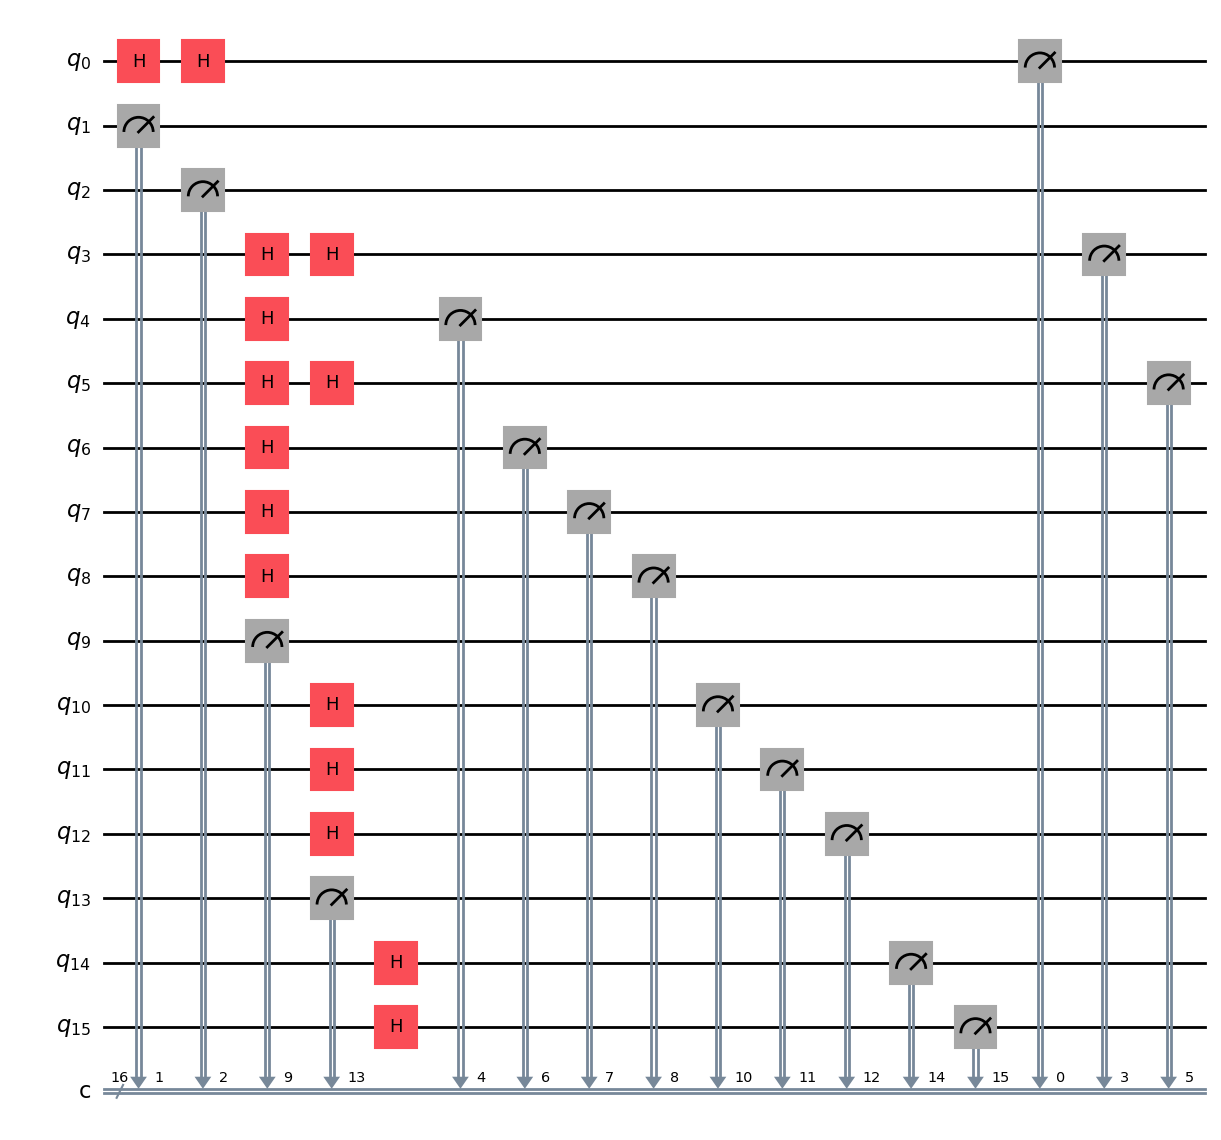

In [ ]:
import random
from qiskit import QuantumCircuit

# Number of bits
n = 16

# Step 1: Alice's bits and state preparation (B92 uses |0⟩ and |+⟩)
alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_states = ['|0>' if bit == 0 else '|+>' for bit in alice_bits]

# Step 2: Bob's random measurement bases (Z or X)
bob_bases = [random.choice(['z', 'x']) for _ in range(n)]

# Step 3: Create the full quantum circuit
qc = QuantumCircuit(n, n)

for i in range(n):
    # Alice encodes the bit
    if alice_bits[i] == 1:
        qc.h(i)  # |+> is created from H|0>

    # Bob applies measurement basis
    if bob_bases[i] == 'x':
        qc.h(i)  # Convert to X basis before measurement

    # Measure the qubit
    qc.measure(i, i)

# Display circuit
print("Alice Bits:  ", alice_bits)
print("Alice States:", alice_states)
print("Bob Bases:   ", bob_bases)
qc.draw('mpl')



--- B92 Simulation Summary ---
Alice Bits:      [1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1]
Alice States:    ['|+>', '|0>', '|+>', '|+>', '|+>', '|+>', '|0>', '|+>', '|0>', '|0>', '|0>', '|0>', '|0>', '|0>', '|+>', '|0>', '|+>', '|0>', '|0>', '|+>', '|0>', '|+>', '|0>', '|0>', '|0>', '|0>', '|+>', '|+>', '|+>', '|+>', '|0>', '|+>']
Bob Bases:       ['x', 'z', 'z', 'z', 'z', 'x', 'x', 'z', 'z', 'z', 'z', 'x', 'z', 'z', 'x', 'x', 'z', 'z', 'z', 'x', 'z', 'x', 'z', 'x', 'x', 'x', 'x', 'x', 'x', 'z', 'z', 'z']
Bob Results:     [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
Matched Indices: [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 30, 31]
Raw Key:         [1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1]
Matched Bits:    27
Unmatched Bits:  5
Error Rate: 18.52%


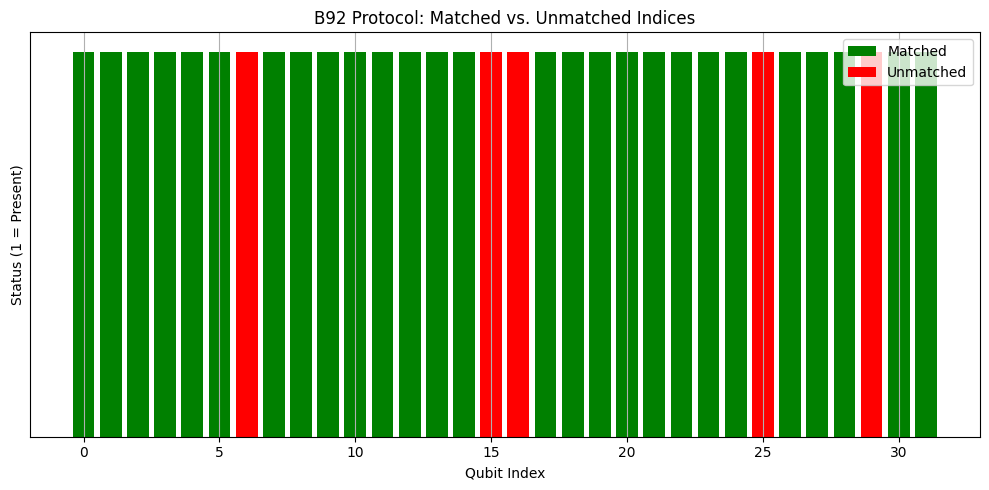

In [ ]:
import random
import matplotlib.pyplot as plt

# Number of bits can be changed according to choice
n = 32

# Step 1: Alice's bit generation (0 → |0>, 1 → |+>)
alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_states = ['|0>' if bit == 0 else '|+>' for bit in alice_bits]

# Step 2: Bob's basis choices (z or x)
bob_bases = [random.choice(['z', 'x']) for _ in range(n)]

# Step 3: Simulate Bob's measurement results
bob_results = []

def measure_b92(state, basis):
    if state == '|0>':
        if basis == 'z':
            return 0
        else:
            return random.choice([0, 1])
    elif state == '|+>':
        if basis == 'x':
            return 0
        else:
            return random.choice([0, 1])

for i in range(n):
    bob_results.append(measure_b92(alice_states[i], bob_bases[i]))

# Step 4: Sifting based on B92 logic
matched_indices = []
unmatched_indices = []
raw_key = []

for i in range(n):
    a_bit = alice_bits[i]
    a_state = alice_states[i]
    b_basis = bob_bases[i]
    b_result = bob_results[i]

    if a_bit == 0 and b_basis == 'x' and b_result == 1:
        unmatched_indices.append(i)
        continue
    elif a_bit == 1 and b_basis == 'z' and b_result == 1:
        unmatched_indices.append(i)
        continue

    matched_indices.append(i)
    raw_key.append(a_bit)

# Step 5: Summary
matched_bits = len(matched_indices)
unmatched_bits = len(unmatched_indices)
error_rate = (unmatched_bits / matched_bits) * 100 if matched_bits else 0

print("\n--- B92 Simulation Summary ---")
print(f"Alice Bits:      {alice_bits}")
print(f"Alice States:    {alice_states}")
print(f"Bob Bases:       {bob_bases}")
print(f"Bob Results:     {bob_results}")
print(f"Matched Indices: {matched_indices}")
print(f"Raw Key:         {raw_key}")
print(f"Matched Bits:    {matched_bits}")
print(f"Unmatched Bits:  {unmatched_bits}")
print(f"Error Rate: {error_rate:.2f}%")

# Step 6: Visualization with colored bars
plt.figure(figsize=(10, 5))

# Plot matched in green
plt.bar(matched_indices, [1]*len(matched_indices), color='green', label='Matched')

# Plot unmatched in red
plt.bar(unmatched_indices, [1]*len(unmatched_indices), color='red', label='Unmatched')

plt.title("B92 Protocol: Matched vs. Unmatched Indices")
plt.xlabel("Qubit Index")
plt.ylabel("Status (1 = Present)")
plt.yticks([])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
